Implement hierarchical clustering on customer dataset. Determine the number of clusters using the elbow method.


Dataset link :
https://www.kaggle.com/code/heeraldedhia/kmeans-clustering-for-customer-data/input

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder,StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering

In [5]:
data = pd.read_csv("D:/KAUSTUBH/LP3 Final/Mall_Customers.csv")

data.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [6]:
# Preprocess the data
# Encode the 'Gender' column as numeric values (Male = 0, Female = 1)
label_encoder = LabelEncoder()
data['Gender'] = label_encoder.fit_transform(data['Gender'])


In [7]:
# Select the relevant columns for clustering (ignoring 'CustomerID' as it's not needed for clustering)
X = data[['Gender', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']]
# Normalize the data for better clustering
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [8]:
# Step 1: Perform Hierarchical Clustering and Visualize the Dendrogram

# Perform hierarchical/agglomerative clustering
linked = linkage(X_scaled, method='ward')

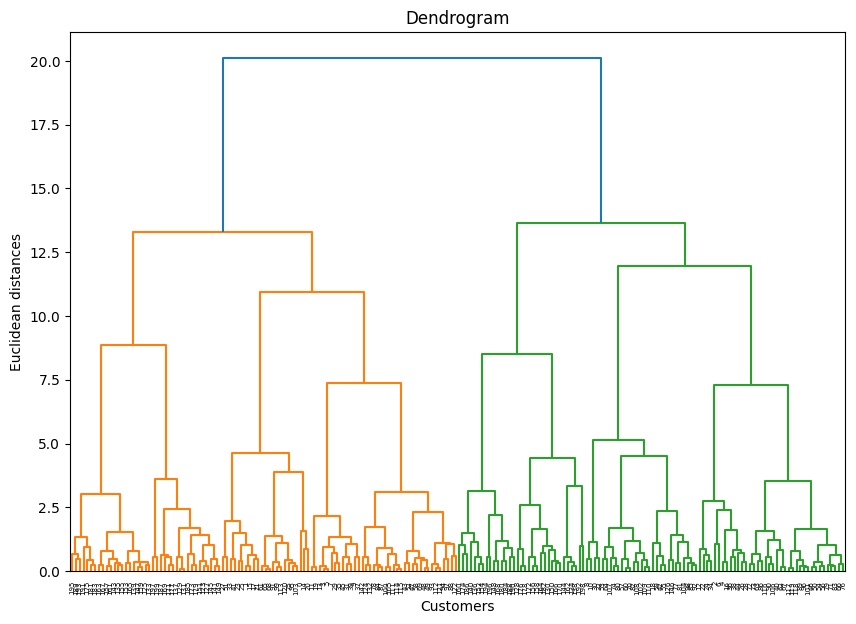

In [9]:
# Plot the dendrogram to visualize the hierarchical structure
plt.figure(figsize=(10, 7))
dendrogram(linked)
plt.title('Dendrogram')
plt.xlabel('Customers')
plt.ylabel('Euclidean distances')
plt.show()

In [10]:
# Step 2: Determine the number of clusters using Silhouette Score

# Calculate the silhouette score for different numbers of clusters
sil_scores = []
for n_clusters in range(2, 11):  # Trying different numbers of clusters
    model = AgglomerativeClustering(n_clusters=n_clusters, linkage='ward')
    cluster_labels = model.fit_predict(X_scaled)
    sil_score = silhouette_score(X_scaled, cluster_labels)
    sil_scores.append(sil_score)

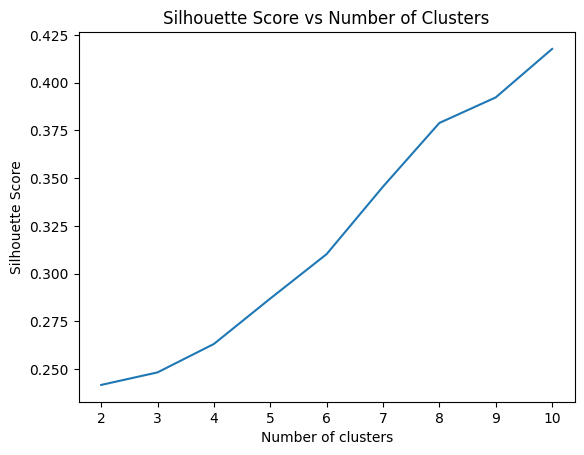

In [11]:
# Plot the silhouette scores to find the optimal number of clusters
plt.plot(range(2, 11), sil_scores)
plt.title('Silhouette Score vs Number of Clusters')
plt.xlabel('Number of clusters')
plt.ylabel('Silhouette Score')
plt.show()

In [12]:
# Step 3: Perform Agglomerative Clustering with the chosen number of clusters

# Assuming the best number of clusters is determined by either the dendrogram or silhouette score (e.g., 5)
best_n_clusters = 2
final_model = AgglomerativeClustering(n_clusters=best_n_clusters, linkage='ward')
final_cluster_labels = final_model.fit_predict(X_scaled)


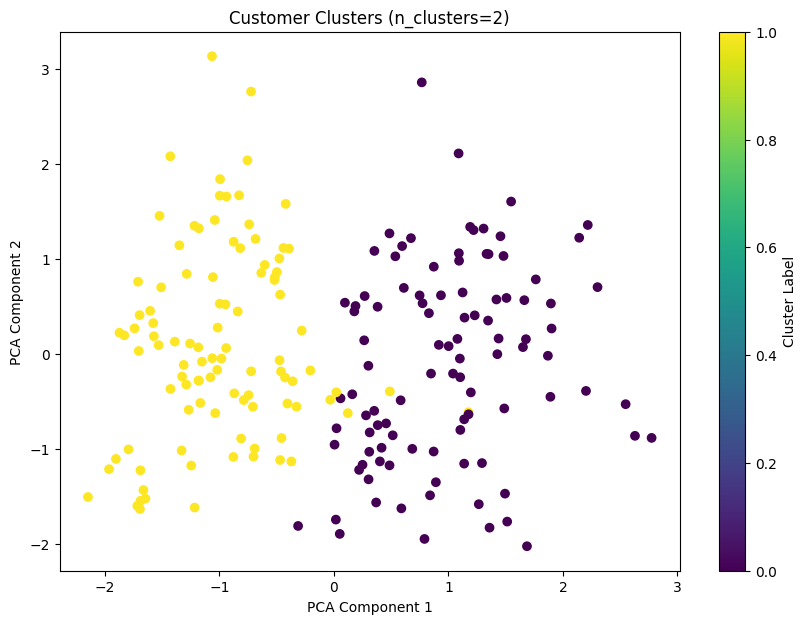

In [13]:
# Step 4: Dimensionality Reduction for Visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Plot the clusters
plt.figure(figsize=(10, 7))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=final_cluster_labels, cmap='viridis', marker='o')
plt.title(f'Customer Clusters (n_clusters={best_n_clusters})')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.colorbar(label='Cluster Label')
plt.show()